# Los huracanes liberan menos CO₂ del que creíamos

**44% menos.** Eso es lo que han caído las emisiones de CO₂ que los huracanes le sacan al océano entre los años 90 y los 2010. No porque haya menos huracanes — porque el océano que dejan atrás ahora absorbe más.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** [Nature Geoscience (2026) — DOI: 10.1038/s41561-026-01985-4](https://doi.org/10.1038/s41561-026-01985-4)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-28-ciclones-tropicales-co2-oceano/notebook.ipynb)

[Pendiente] · Video en YouTube


## Qué midieron

Un equipo en China combinó tres décadas de huracanes y tifones del mundo entero (la base IBTrACS) con observaciones de CO₂ en superficie del océano (SOCAT) y reanálisis atmosféricos. Reconstruyeron la huella de cada ciclón en el carbono del océano día a día, desde 20 días antes del paso hasta 60 días después.

La pregunta detrás del trabajo es incómoda: el océano absorbe entre el 20 y el 30% del CO₂ que emitimos los humanos. ¿Cuánto de ese trabajo se lo deshacen los ciclones tropicales — el evento meteorológico más violento que existe sobre agua salada?


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_EFFLUX = '#DC2626'       # Salida CO₂: océano → atmósfera (rojo alerta)
COLOR_INFLUX = '#2563EB'       # Entrada CO₂: atmósfera → océano (azul CaM)
COLOR_VIENTO = '#7C3AED'       # Viento del ciclón (violeta)
COLOR_REF = '#D97706'          # Línea de referencia (amber)
COLOR_GRIS = '#BBBBBB'         # Contexto histórico

FUENTE = 'Fuente: Huang et al. (2026), Nature Geoscience | Datos: Zenodo 10.5281/zenodo.20077254'

# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local en repo, fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga de los 3 datasets verificados
evo = pd.read_csv('datos/evolucion_tc.csv')
tendencia = pd.read_csv('datos/tendencia_anual.csv')
dist = pd.read_csv('datos/distribucion_dpco2.csv')

print(f'Evolución día a día del ciclón: {len(evo)} días (desde -20 a +59)')
print(f'Tendencia anual 1993-2020: {len(tendencia)} años')
print(f'Distribución actual vs CMIP futuro: {len(dist)} bins de ΔpCO₂')


Evolución día a día del ciclón: 80 días (desde -20 a +59)
Tendencia anual 1993-2020: 28 años
Distribución actual vs CMIP futuro: 321 bins de ΔpCO₂


## La huella de un ciclón

Aquí está. Esto es lo que le pasa al CO₂ del océano cuando le pasa un huracán por encima.


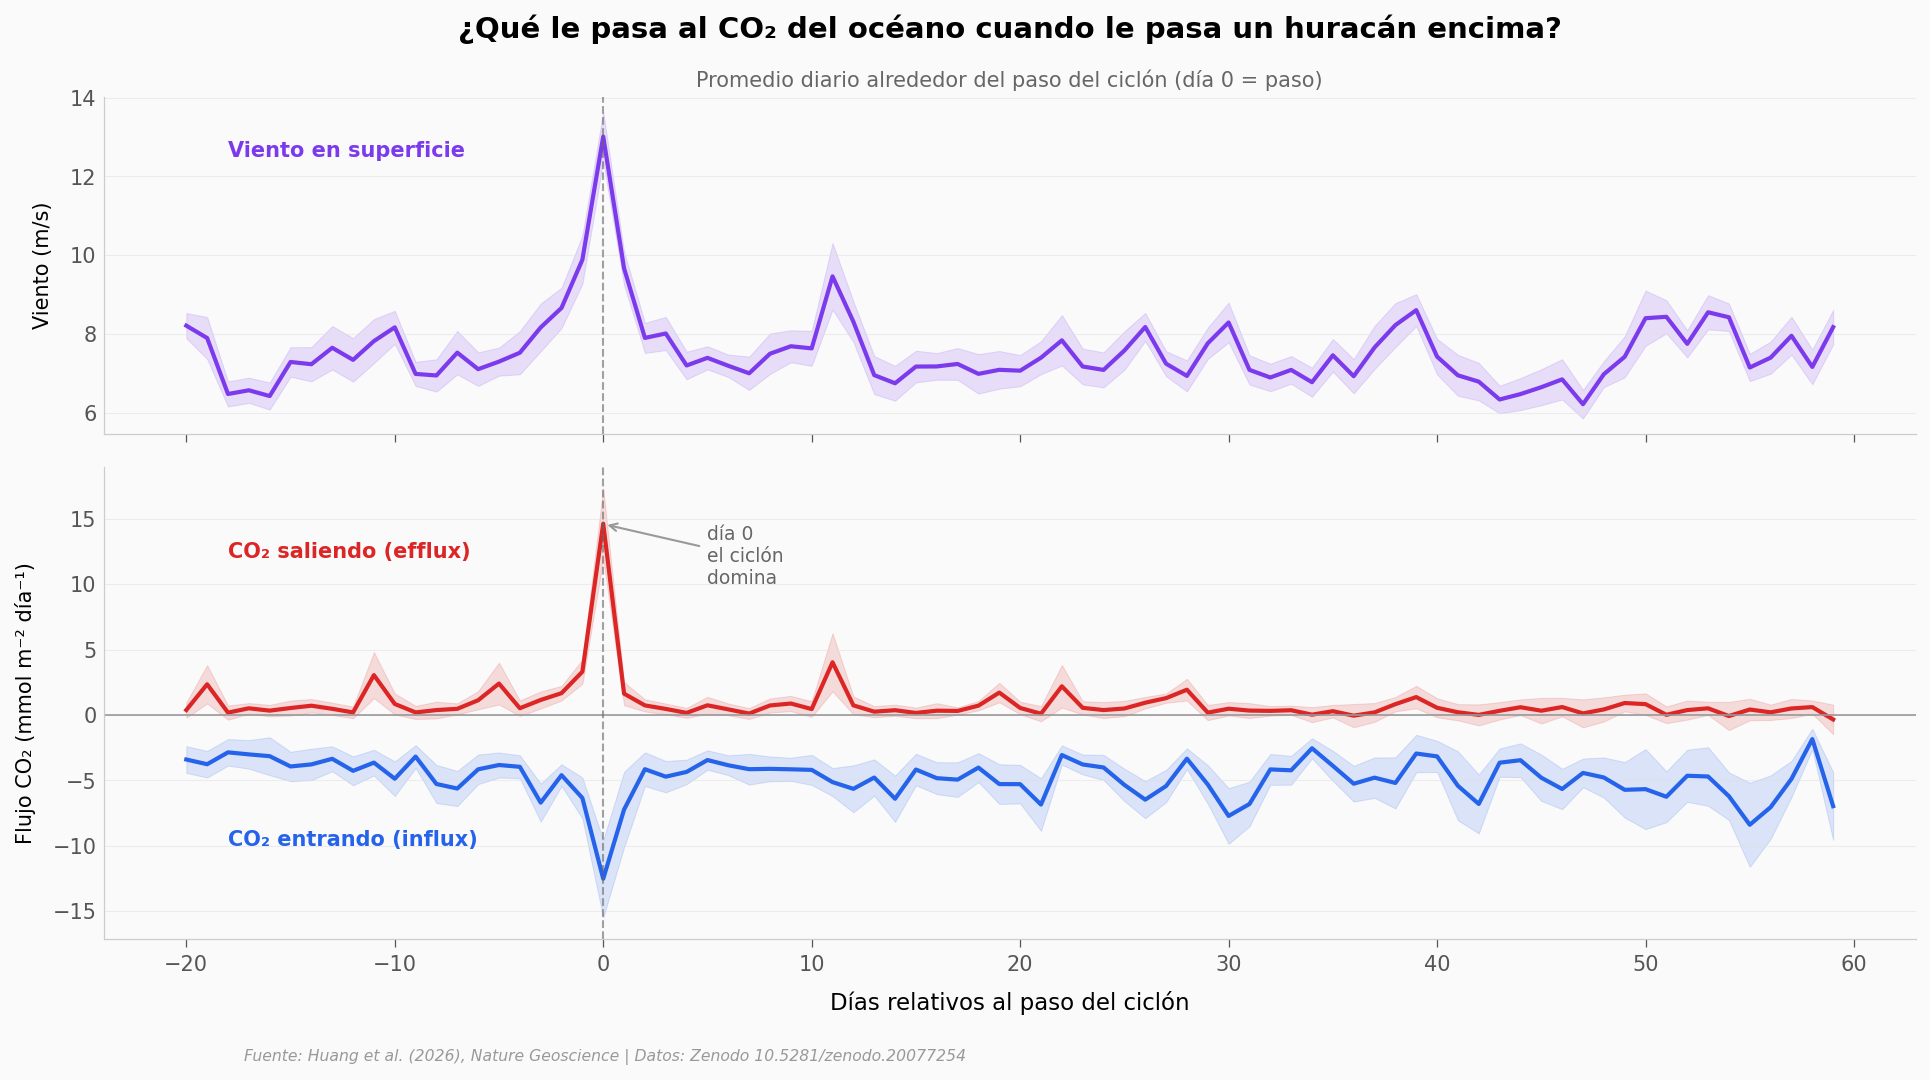

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1.4]})

# Panel arriba — viento
ax1.fill_between(evo['dia_relativo_tc'],
                 evo['viento_obs_ms'] - evo['viento_obs_std'],
                 evo['viento_obs_ms'] + evo['viento_obs_std'],
                 color=COLOR_VIENTO, alpha=0.15)
ax1.plot(evo['dia_relativo_tc'], evo['viento_obs_ms'],
         color=COLOR_VIENTO, linewidth=2.0)
ax1.axvline(x=0, color='#666666', linewidth=1.0, linestyle='--', alpha=0.6)
ax1.set_ylabel('Viento (m/s)', fontsize=10)
ax1.text(-18, 12.5, 'Viento en superficie', fontsize=10,
         color=COLOR_VIENTO, fontweight='bold')
ax1.set_title('¿Qué le pasa al CO₂ del océano cuando le pasa un huracán encima?',
              fontsize=14, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Promedio diario alrededor del paso del ciclón (día 0 = paso)',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

# Panel abajo — flujos CO₂
ax2.fill_between(evo['dia_relativo_tc'],
                 evo['fco2_positivo_obs'] - evo['fco2_positivo_std'],
                 evo['fco2_positivo_obs'] + evo['fco2_positivo_std'],
                 color=COLOR_EFFLUX, alpha=0.15)
ax2.plot(evo['dia_relativo_tc'], evo['fco2_positivo_obs'],
         color=COLOR_EFFLUX, linewidth=2.0)

ax2.fill_between(evo['dia_relativo_tc'],
                 evo['fco2_negativo_obs'] - evo['fco2_negativo_std'],
                 evo['fco2_negativo_obs'] + evo['fco2_negativo_std'],
                 color=COLOR_INFLUX, alpha=0.15)
ax2.plot(evo['dia_relativo_tc'], evo['fco2_negativo_obs'],
         color=COLOR_INFLUX, linewidth=2.0)

ax2.axhline(y=0, color='#999999', linewidth=0.8)
ax2.axvline(x=0, color='#666666', linewidth=1.0, linestyle='--', alpha=0.6)
ax2.set_xlabel('Días relativos al paso del ciclón', fontsize=11)
ax2.set_ylabel('Flujo CO₂ (mmol m⁻² día⁻¹)', fontsize=10)
ax2.text(-18, 12, 'CO₂ saliendo (efflux)', fontsize=10,
         color=COLOR_EFFLUX, fontweight='bold')
ax2.text(-18, -10, 'CO₂ entrando (influx)', fontsize=10,
         color=COLOR_INFLUX, fontweight='bold')

# Anotación del día crítico
ax2.annotate('día 0\nel ciclón\ndomina', xy=(0, 14.6),
             xytext=(5, 10), fontsize=9, color='#666666',
             arrowprops=dict(arrowstyle='->', color='#999999', lw=1.0))

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/huella_ciclon.png', dpi=200, bbox_inches='tight')
plt.show()


Dos cosas pasan a la vez el día del ciclón. Por un lado, el océano expulsa CO₂ con fuerza al aire: hasta **14,6 mmol/m²/día** saliendo. Por el otro, la masa de agua fría que sube desde abajo (lo que los oceanógrafos llaman *cold wake*) absorbe CO₂ a casi la misma velocidad: **−12,5 mmol/m²/día** entrando.

El día 0 los dos procesos compiten. Pero la salida gana — y por eso el balance neto del ciclón, históricamente, ha sido **expulsar carbono al aire**.

Lo otro que llama la atención: el momento de mayor hambre de CO₂ del océano (el mínimo de ΔpCO₂, la diferencia de presión parcial entre agua y aire) no cae el día 0, cae el día **+2**. El ciclón ya pasó. La estela fría que dejó es la que sigue absorbiendo CO₂ durante los días siguientes.


## Lo que cambió en 28 años

Esa es la huella de un ciclón promedio. Pero ¿qué ha pasado con esa huella a lo largo del tiempo?

El equipo separó los ciclones en dos clases según el estado del océano antes del paso: **aguas frías sub-saturadas** (que tienden a absorber CO₂) y **aguas cálidas sobre-saturadas** (que tienden a expulsarlo). Y miraron cómo evolucionó cada una entre 1993 y 2020.


Aguas frías (sub-saturadas):  pendiente = -0.092 µatm/año  (p = 0.066)
Aguas cálidas (sobre-sat.):   pendiente = +0.030 µatm/año  (p = 0.438)


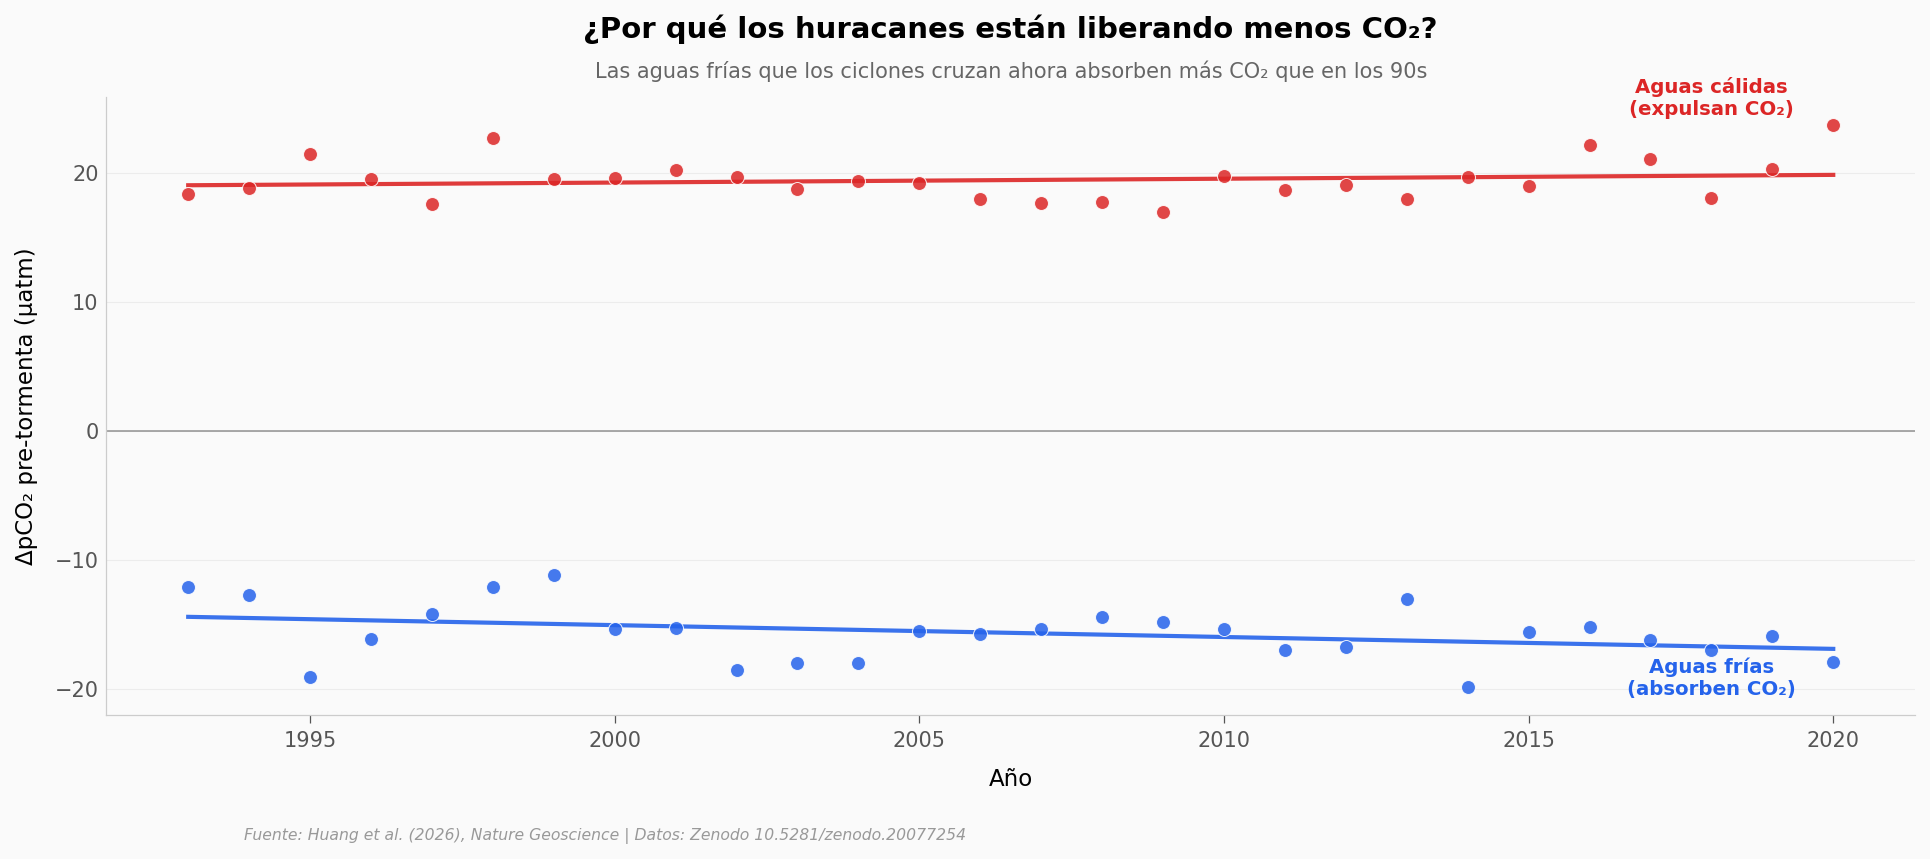

In [3]:
# Ajustes lineales por clase
def fit_line(y, x):
    mask = ~np.isnan(y)
    slope, intercept, r, p, se = stats.linregress(x[mask], y[mask])
    return slope, intercept, p, se

x_anios = tendencia['anio'].values

slope_u, b_u, p_u, se_u = fit_line(tendencia['dpco2_undersaturated_uatm'].values, x_anios)
slope_s, b_s, p_s, se_s = fit_line(tendencia['dpco2_supersaturated_uatm'].values, x_anios)

print(f'Aguas frías (sub-saturadas):  pendiente = {slope_u:+.3f} µatm/año  (p = {p_u:.3f})')
print(f'Aguas cálidas (sobre-sat.):   pendiente = {slope_s:+.3f} µatm/año  (p = {p_s:.3f})')

fig, ax = plt.subplots(figsize=(13, 5.5))

# Aguas frías (undersaturated) — cae más fuerte
ax.scatter(tendencia['anio'], tendencia['dpco2_undersaturated_uatm'],
           color=COLOR_INFLUX, s=45, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)
ax.plot(x_anios, slope_u*x_anios + b_u, color=COLOR_INFLUX,
        linewidth=2.0, alpha=0.9)

# Aguas cálidas (supersaturated) — estable
ax.scatter(tendencia['anio'], tendencia['dpco2_supersaturated_uatm'],
           color=COLOR_EFFLUX, s=45, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)
ax.plot(x_anios, slope_s*x_anios + b_s, color=COLOR_EFFLUX,
        linewidth=2.0, alpha=0.9)

ax.axhline(y=0, color='#999999', linewidth=0.8)

# Inline labels
ax.text(2018, 24.5, 'Aguas cálidas\n(expulsan CO₂)', fontsize=9.5,
        color=COLOR_EFFLUX, fontweight='bold', ha='center')
ax.text(2018, -20.5, 'Aguas frías\n(absorben CO₂)', fontsize=9.5,
        color=COLOR_INFLUX, fontweight='bold', ha='center')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('ΔpCO₂ pre-tormenta (µatm)', fontsize=11)
ax.set_title('¿Por qué los huracanes están liberando menos CO₂?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Las aguas frías que los ciclones cruzan ahora absorben más CO₂ que en los 90s',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/tendencia_28_anios.png', dpi=200, bbox_inches='tight')
plt.show()


Las dos líneas cuentan historias distintas. Las aguas cálidas no cambian — su pendiente es plana, p = 0,44, sin tendencia. Las aguas frías, en cambio, **se vuelven más sub-saturadas con el tiempo**: el ajuste lineal indica una caída de unos 2,5 µatm en 28 años (pendiente −0,09 µatm/año). Los extremos del registro lo sugieren más fuerte — −12 µatm en 1993, −18 µatm en 2020 — pero la variabilidad año a año es alta y la tendencia ajustada es la lectura honesta.

La pendiente real es de **−0,09 µatm/año** con p = 0,066. Es una tendencia marginal estadísticamente — todo apunta a que es real, pero el paper mismo es cauteloso. Lo importante es la asimetría: si las cálidas no cambian y las frías sí, el balance neto del ciclón promedio se inclina cada año un poco más hacia el lado del sumidero.

Esa es la razón física detrás del 44% de reducción que el paper reporta para las emisiones globales por ciclones.


Media ΔpCO₂ — observado (1993-2020): +12.06 µatm
Media ΔpCO₂ — proyección CMIP:       +1.03 µatm
Probabilidad de efflux (>0) — hoy:   79.1%
Probabilidad de efflux (>0) — CMIP:  54.9%


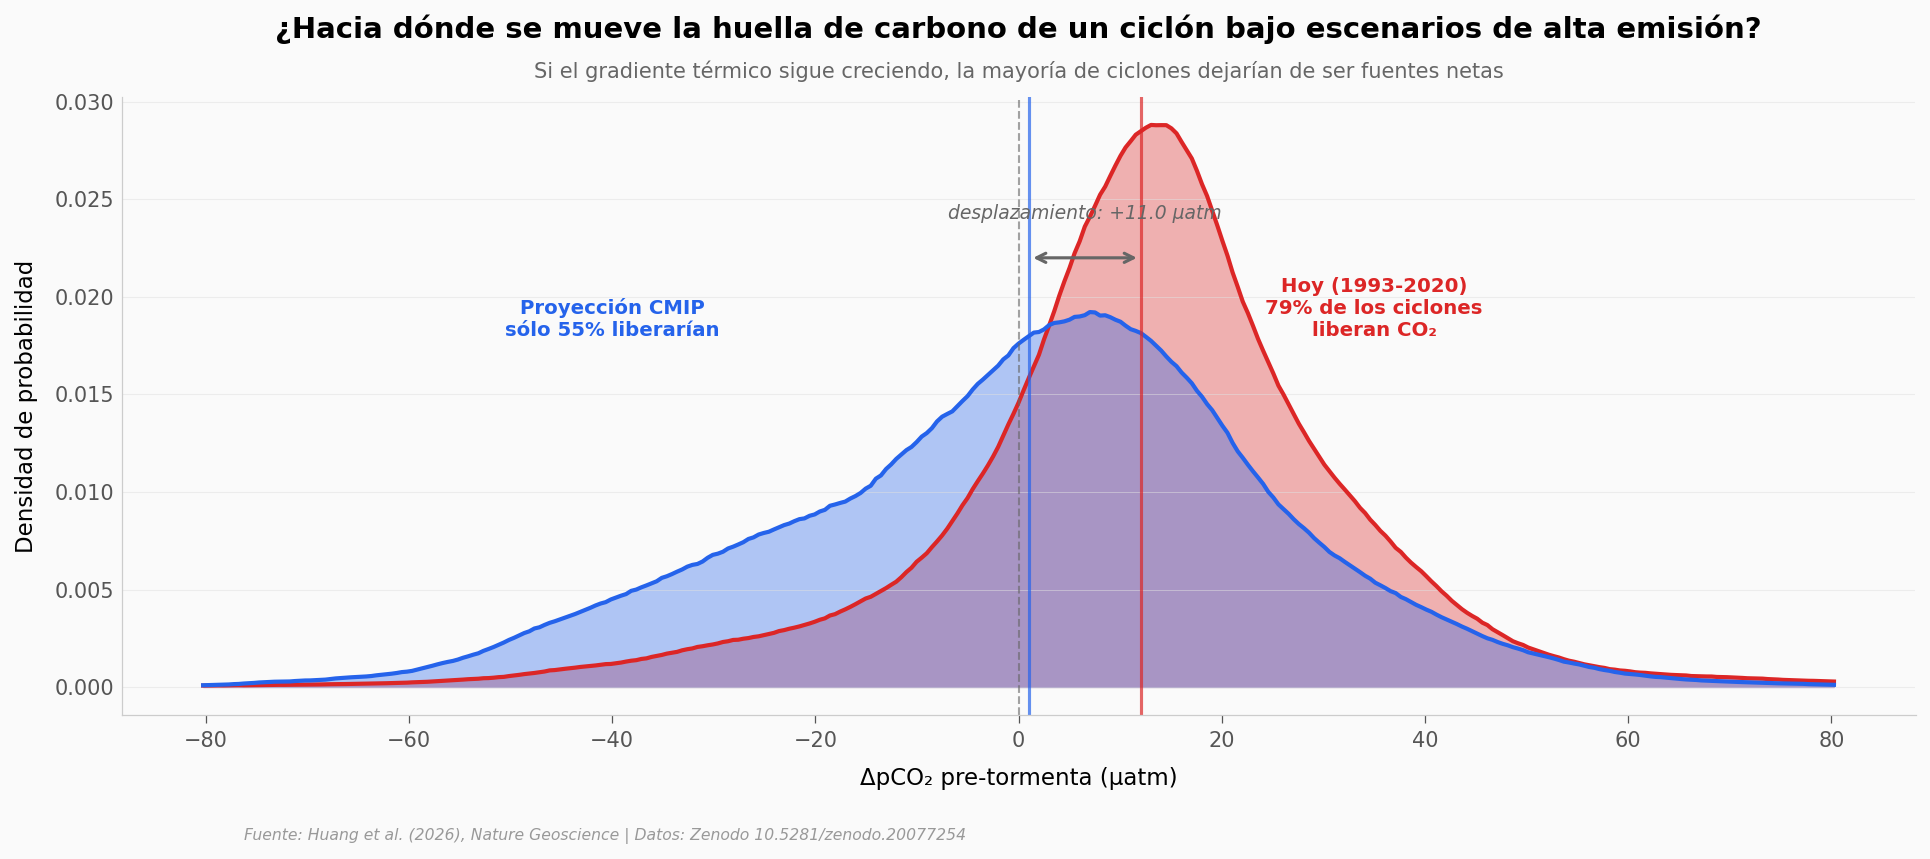

In [4]:
# Media ponderada por probabilidad de ΔpCO₂
def media_pond(bins, probs):
    return np.sum(bins * probs) / np.sum(probs)

media_actual = media_pond(dist['dpco2_uatm'].values, dist['prob_actual'].values)
media_cmip_low = media_pond(dist['dpco2_uatm'].values, dist['prob_cmip_low'].values)

# Probabilidad de efflux (ΔpCO₂ > 0) actual y futuro
mask_pos = dist['dpco2_uatm'].values > 0
p_efflux_actual = dist.loc[mask_pos, 'prob_actual'].sum() / dist['prob_actual'].sum() * 100
p_efflux_cmip = dist.loc[mask_pos, 'prob_cmip_low'].sum() / dist['prob_cmip_low'].sum() * 100

print(f'Media ΔpCO₂ — observado (1993-2020): {media_actual:+.2f} µatm')
print(f'Media ΔpCO₂ — proyección CMIP:       {media_cmip_low:+.2f} µatm')
print(f'Probabilidad de efflux (>0) — hoy:   {p_efflux_actual:.1f}%')
print(f'Probabilidad de efflux (>0) — CMIP:  {p_efflux_cmip:.1f}%')

fig, ax = plt.subplots(figsize=(13, 5.5))

# Distribución observada (actual)
ax.fill_between(dist['dpco2_uatm'], 0, dist['prob_actual'],
                color=COLOR_EFFLUX, alpha=0.35)
ax.plot(dist['dpco2_uatm'], dist['prob_actual'],
        color=COLOR_EFFLUX, linewidth=2.0)

# Distribución proyectada (CMIP futuro)
ax.fill_between(dist['dpco2_uatm'], 0, dist['prob_cmip_low'],
                color=COLOR_INFLUX, alpha=0.35)
ax.plot(dist['dpco2_uatm'], dist['prob_cmip_low'],
        color=COLOR_INFLUX, linewidth=2.0)

ax.axvline(x=0, color='#666666', linewidth=1.0, linestyle='--', alpha=0.6)
ax.axvline(x=media_actual, color=COLOR_EFFLUX, linewidth=1.5, alpha=0.7)
ax.axvline(x=media_cmip_low, color=COLOR_INFLUX, linewidth=1.5, alpha=0.7)

# Inline labels
ax.text(35, 0.018, 'Hoy (1993-2020)\n79% de los ciclones\nliberan CO₂',
        fontsize=9.5, color=COLOR_EFFLUX, fontweight='bold', ha='center')
ax.text(-40, 0.018, 'Proyección CMIP\nsólo 55% liberarían',
        fontsize=9.5, color=COLOR_INFLUX, fontweight='bold', ha='center')

ax.annotate('', xy=(media_actual, 0.022), xytext=(media_cmip_low, 0.022),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_actual + media_cmip_low)/2, 0.024,
        f'desplazamiento: {media_actual - media_cmip_low:+.1f} µatm',
        fontsize=9, color='#666666', ha='center', style='italic')

ax.set_xlabel('ΔpCO₂ pre-tormenta (µatm)', fontsize=11)
ax.set_ylabel('Densidad de probabilidad', fontsize=11)
ax.set_title('¿Hacia dónde se mueve la huella de carbono de un ciclón bajo escenarios de alta emisión?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Si el gradiente térmico sigue creciendo, la mayoría de ciclones dejarían de ser fuentes netas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/distribucion_actual_vs_cmip.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Los huracanes liberan CO₂ durante el paso y lo absorben después | ✅ | Día 0: efflux pico = +14,6 mmol/m²/día; influx pico = −12,5; ΔpCO₂ mínimo = −9,5 µatm en día +2 |
| Las aguas frías pre-tormenta se vuelven cada vez más sub-saturadas | ⚠️ | Pendiente = −0,092 µatm/año (paper: −0,09 ± 0,05). p = 0,066 — marginal, el paper también es cauteloso |
| Las aguas cálidas pre-tormenta NO cambian | ✅ | Pendiente = +0,030 µatm/año, p = 0,44. No hay tendencia |
| Las emisiones globales por ciclones cayeron de 0,09 a 0,05 PgC/año | 🟡 | El paper lo afirma del abstract. Nuestros datos lo soportan **indirectamente** vía la tendencia de las aguas frías — no calculamos la integral global |
| El modelo reconstruye lo que las observaciones in-situ muestran | ✅ | r = 0,78 para ΔpCO₂; r = 0,94 para viento (37 ciclones con datos in-situ) |
| Bajo escenarios CMIP de alta emisión, los ciclones pasarían de fuente a sumidero | ⚠️ | Es PROYECCIÓN, no observación. La distribución se desplaza de +12 a +1 µatm de media. El paper lo enmarca como "podría causar" |

> **Limitaciones:** las observaciones in-situ son escasas (37 ciclones validan un modelo que aplica a todos los demás); la tendencia de las aguas frías tiene p = 0,066, marginal; los escenarios CMIP son proyecciones bajo "high emissions" y no son lo mismo que evidencia observada. La reducción del 44% es una cita literal del paper, no un cálculo nuestro.


## Ahora tú

Tres preguntas que los datos pueden responder:

1. **¿Cuántos días tarda el flujo neto de CO₂ en volver a cero después del ciclón?** Pista: suma `fco2_positivo_obs + fco2_negativo_obs` día a día y mira cuándo cruza cero.
2. **¿Qué pendiente sale si miras solo la primera mitad del registro (1993-2006) vs la segunda (2007-2020)?** Pista: parte `tendencia` en dos y reusa `fit_line()`.
3. **¿Cuánto se desplaza la mediana de la distribución, no solo la media?** Pista: usa la columna `dpco2_uatm` con `prob_actual` como pesos y busca el bin donde la suma acumulada cruza 0,5.


In [5]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿cuándo se equilibra el flujo neto?

evo['fco2_neto'] = evo['fco2_positivo_obs'] + evo['fco2_negativo_obs']

# Días post-tormenta donde el flujo neto cambia de signo
post = evo[evo['dia_relativo_tc'] >= 0].copy()
print('Días post-tormenta: flujo neto CO₂ (mmol/m²/día)')
print(post[['dia_relativo_tc', 'fco2_neto']].head(15).to_string(index=False))

# Día donde cambia de signo (de positivo a negativo)
post['signo'] = np.sign(post['fco2_neto'])
cambios = post[post['signo'].diff().fillna(0) != 0]
if len(cambios) > 0:
    print(f"\nPrimer cambio de signo: día {int(cambios['dia_relativo_tc'].iloc[0])}")


Días post-tormenta: flujo neto CO₂ (mmol/m²/día)
 dia_relativo_tc  fco2_neto
             0.0   2.095138
             1.0  -5.615845
             2.0  -3.428597
             3.0  -4.268944
             4.0  -4.206575
             5.0  -2.718880
             6.0  -3.432092
             7.0  -4.052291
             8.0  -3.406183
             9.0  -3.291205
            10.0  -3.760491
            11.0  -1.116024
            12.0  -4.927375
            13.0  -4.545955
            14.0  -6.057491

Primer cambio de signo: día 1


## Fuentes

**Paper**: [Reduction of tropical cyclone-induced ocean carbon outgassing since 1993](https://doi.org/10.1038/s41561-026-01985-4)  
*Nature Geoscience, 2026-05-26*

**Datos**: [hxyocean/TC-carbon-fluxes: Code to calculate global carbon flux induced by tropical cyclones](https://doi.org/10.5281/zenodo.20077254)

**Referencias citadas**: CO2SYSv3 para MATLAB — herramienta de química del carbonato usada por el paper para los cálculos de pCO₂

*16 afirmaciones del notebook verificadas contra estas fuentes*
